In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
ts = df['Passengers'].astype(float)

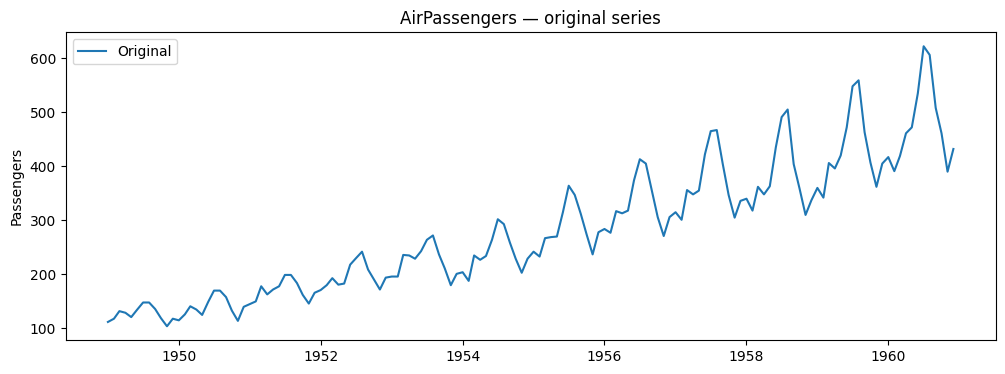

In [7]:
plt.figure(figsize=(12,4))
plt.plot(ts, label='Original')
plt.title('AirPassengers — original series')
plt.ylabel('Passengers')
plt.legend()
plt.show()

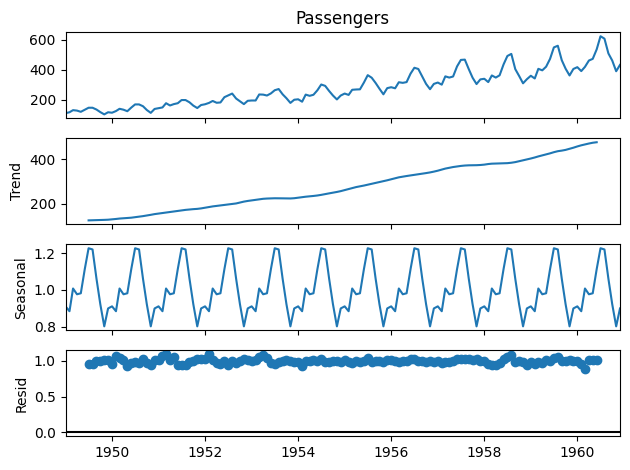

In [8]:
res = seasonal_decompose(ts, model='multiplicative', period=12)
res.plot()
plt.show()

In [10]:
def adf_test(series, autolag='AIC'):
    print(">>> Augmented Dickey-Fuller test")
    adf_res = adfuller(series, autolag=autolag)
    print(f"ADF Statistic: {adf_res[0]:.4f}")
    print(f"p-value: {adf_res[1]:.4f}")
    print("Critical Values:")
    for k, v in adf_res[4].items():
        print(f"  {k}: {v:.4f}")
    return adf_res

def kpss_test(series, regression='c', nlags='auto'):
    print(">>> KPSS test")
    kpss_res = kpss(series, regression=regression, nlags=nlags)
    print(f"KPSS Statistic: {kpss_res[0]:.4f}")
    print(f"p-value: {kpss_res[1]:.4f}")
    print("Critical Values:")
    for k, v in kpss_res[3].items():
        print(f"  {k}: {v:.4f}")
    return kpss_res

adf_res_orig = adf_test(ts)

>>> Augmented Dickey-Fuller test
ADF Statistic: 0.8154
p-value: 0.9919
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788


Fail to reject null hypothesis (H₀).

The series has a unit root → it is not stationary.

In [11]:
kpss_res_orig = kpss_test(ts)

>>> KPSS test
KPSS Statistic: 1.6513
p-value: 0.0100
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


Reject null hypothesis (H₀).

The series is not stationary (it has a trend or non-constant mean).

ADF p-value likely > 0.05 → fail to reject → non-stationary

KPSS p-value likely < 0.05 → reject → non-stationary

## Transformations to induce stationarity

### 1) Log transform (stabilize variance)

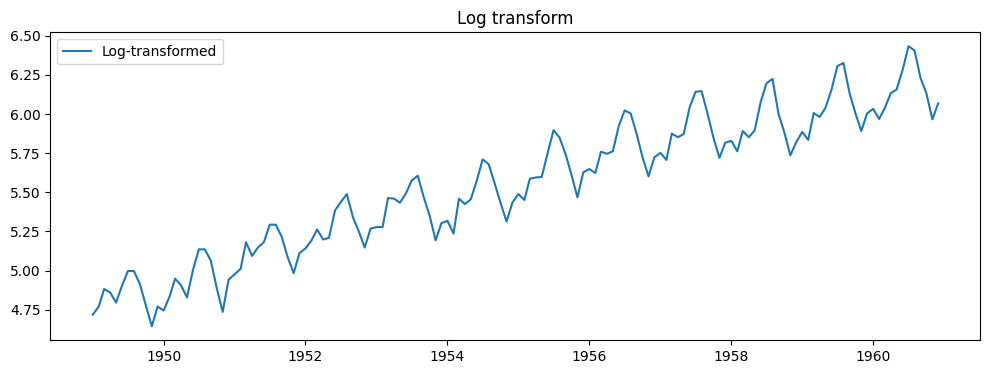

>>> Augmented Dickey-Fuller test
ADF Statistic: -1.7170
p-value: 0.4224
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

>>> KPSS test
KPSS Statistic: 1.6687
p-value: 0.0100
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


(1.6686513235125748,
 0.01,
 8,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [12]:
ts_log = np.log(ts)

plt.figure(figsize=(12,4))
plt.plot(ts_log, label='Log-transformed')
plt.title('Log transform')
plt.legend()
plt.show()

adf_test(ts_log); print(); kpss_test(ts_log)

### 2) First difference (remove trend)

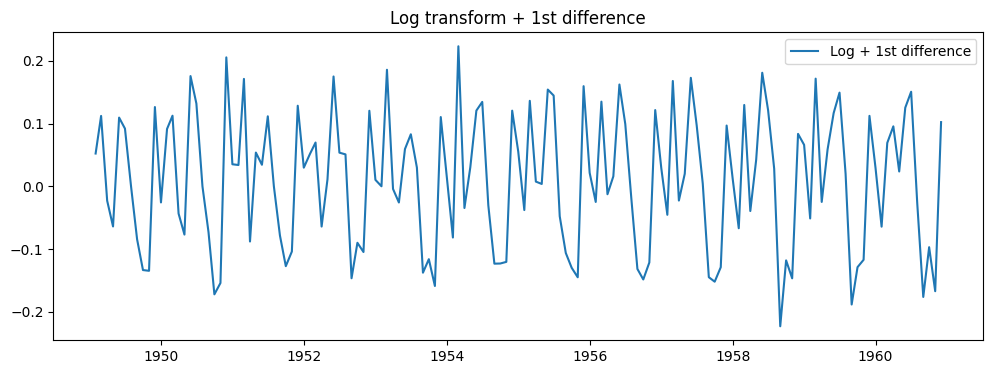

>>> Augmented Dickey-Fuller test
ADF Statistic: -2.7171
p-value: 0.0711
Critical Values:
  1%: -3.4825
  5%: -2.8844
  10%: -2.5790

>>> KPSS test
KPSS Statistic: 0.0383
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


(0.03830446954674065,
 0.1,
 6,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [13]:
ts_log_diff1 = ts_log.diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(ts_log_diff1, label='Log + 1st difference')
plt.title('Log transform + 1st difference')
plt.legend()
plt.show()

adf_test(ts_log_diff1); print(); kpss_test(ts_log_diff1)

### 3) Seasonal difference (period = 12 for monthly)

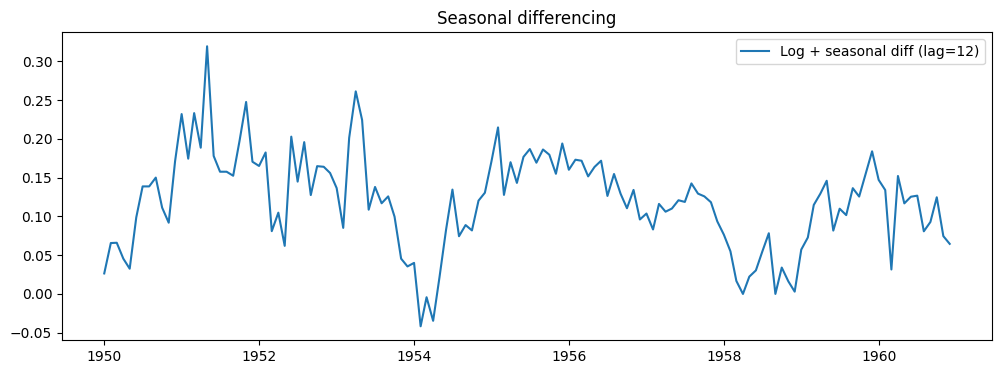

>>> Augmented Dickey-Fuller test
ADF Statistic: -2.7096
p-value: 0.0724
Critical Values:
  1%: -3.4865
  5%: -2.8862
  10%: -2.5799

>>> KPSS test
KPSS Statistic: 0.2918
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


(0.2918323624936068,
 0.1,
 6,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [14]:
seasonal_period = 12
ts_log_seasdiff = ts_log.diff(seasonal_period).dropna()

plt.figure(figsize=(12,4))
plt.plot(ts_log_seasdiff, label=f'Log + seasonal diff (lag={seasonal_period})')
plt.title('Seasonal differencing')
plt.legend()
plt.show()

adf_test(ts_log_seasdiff); print(); kpss_test(ts_log_seasdiff)


### 4) Combined (seasonal + first difference) — common for SARIMA

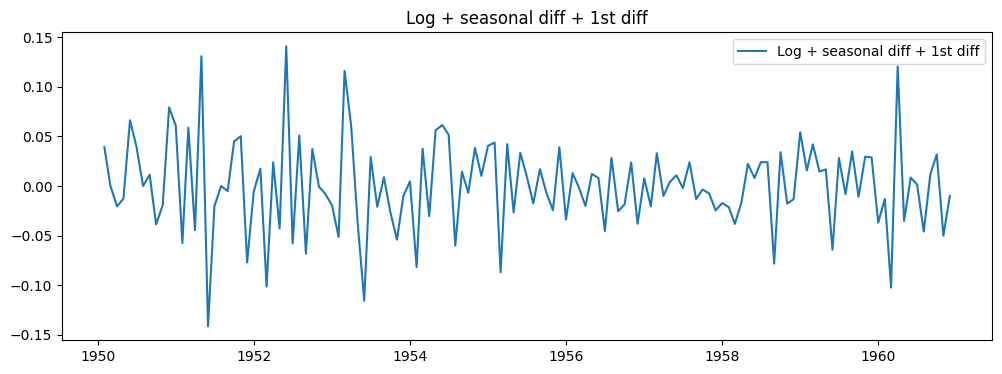

>>> Augmented Dickey-Fuller test
ADF Statistic: -4.4433
p-value: 0.0002
Critical Values:
  1%: -3.4870
  5%: -2.8864
  10%: -2.5800

>>> KPSS test
KPSS Statistic: 0.0732
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


(0.07319096983125449,
 0.1,
 3,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [15]:
ts_log_seasdiff_diff1 = ts_log.diff(seasonal_period).diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(ts_log_seasdiff_diff1, label='Log + seasonal diff + 1st diff')
plt.title('Log + seasonal diff + 1st diff')
plt.legend()
plt.show()

adf_test(ts_log_seasdiff_diff1); print(); kpss_test(ts_log_seasdiff_diff1)


### Detrend by regression (remove deterministic linear trend)

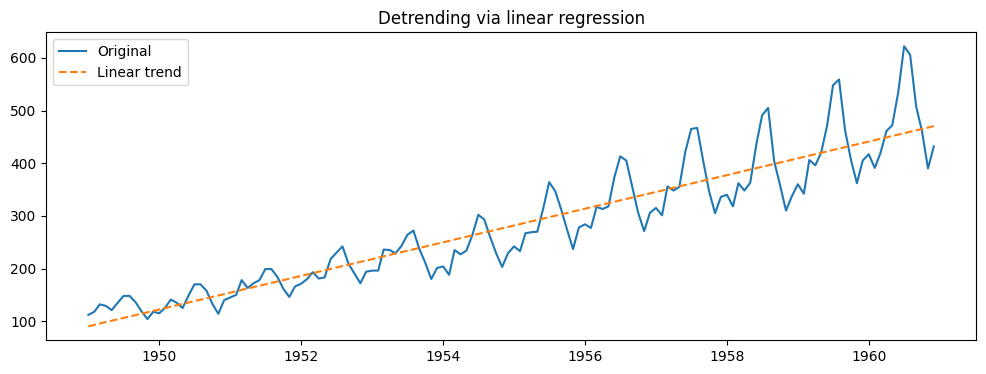

>>> Augmented Dickey-Fuller test
ADF Statistic: -2.1020
p-value: 0.2437
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

>>> KPSS test
KPSS Statistic: 0.0961
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


C:\Users\aksha\AppData\Local\Temp\ipykernel_17868\1585978152.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression=regression, nlags=nlags)


(0.0961498485353271,
 0.1,
 4,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [16]:
from sklearn.linear_model import LinearRegression

# Build time index
X = np.arange(len(ts)).reshape(-1, 1)
y = ts.values

lr = LinearRegression()
lr.fit(X, y)
trend = lr.predict(X)

# create detrended series (original - linear trend)
ts_detrended = pd.Series(y - trend, index=ts.index)

plt.figure(figsize=(12,4))
plt.plot(ts, label='Original')
plt.plot(ts.index, trend, label='Linear trend', linestyle='--')
plt.title('Detrending via linear regression')
plt.legend()
plt.show()

# Test stationarity on detrended series
adf_test(ts_detrended.dropna()); print(); kpss_test(ts_detrended.dropna())


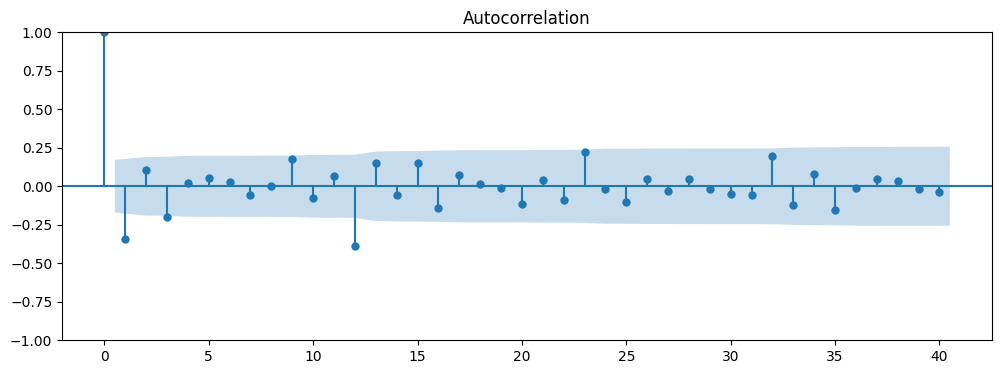

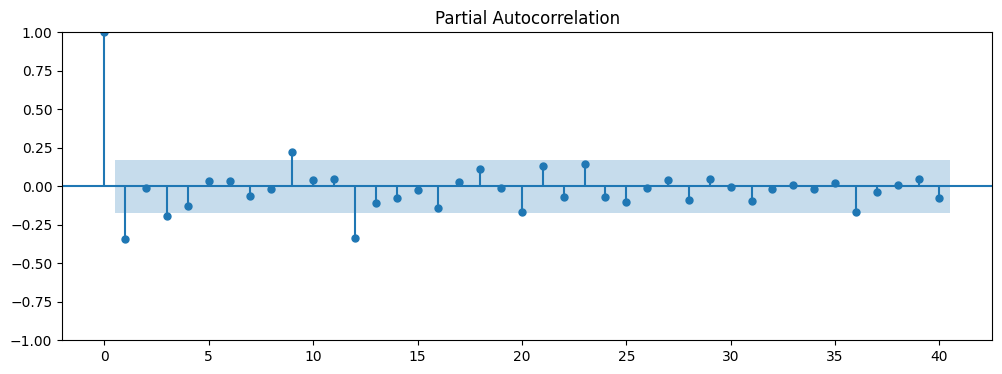

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(ts_log_seasdiff_diff1, lags=40, ax=plt.gca())
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(ts_log_seasdiff_diff1, lags=40, ax=plt.gca(), method='ywm')
plt.show()
